# 03. 액션 마스킹과 비선형 액션 매핑

논문의 실험 B(마스킹)와 실험 C(비선형 매핑)에 해당하는 두 스위치를 살펴봅니다.

* `ENABLE_ACTION_MASK`, `MASK_RULE_TYPE ∈ {basic, enhanced}` — **안전층(safety layer)**: 제약을 위반할 액션을 샘플링 전에 제거
* `ENABLE_NONLINEAR_MAPPING`, `NONLINEAR_MAPPING_TYPE ∈ {square, sqrt, cubic, exp, log}` — 100개 이산 액션을 방류량에 어떻게 대응시킬지

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, ".")
import toy_reservoir as tr
plt.rcParams["figure.figsize"] = (11, 3.4)

## 1. 비선형 매핑: 이산 액션 → 방류량

액션 인덱스 `a ∈ {0..99}` 를 `u = a/99` 로 정규화한 뒤 함수 `f(u)` 를 거쳐 `[Q_MIN, Q_MAX]` 에 매핑합니다. 함수에 따라 **저방류 구간과 고방류 구간의 해상도**가 달라집니다.

Text(0.5, 1.0, 'resolution of the discrete grid')

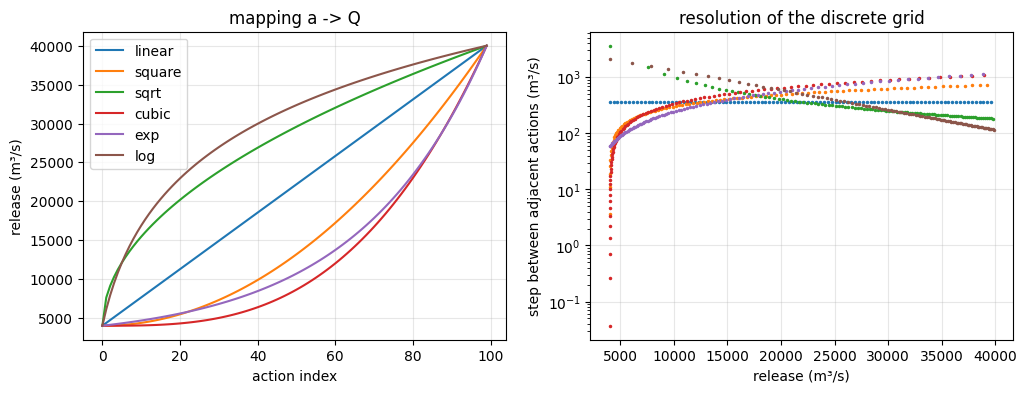

In [2]:
mappings = ["linear", "square", "sqrt", "cubic", "exp", "log"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
for m in mappings:
    g = tr.release_grid(m)
    a1.plot(np.arange(100), g, label=m)
    a2.plot(g[:-1], np.diff(g), ".", ms=3, label=m)
a1.set_xlabel("action index"); a1.set_ylabel("release (m³/s)"); a1.legend(); a1.grid(alpha=.3); a1.set_title("mapping a -> Q")
a2.set_xlabel("release (m³/s)"); a2.set_ylabel("step between adjacent actions (m³/s)"); a2.set_yscale("log"); a2.grid(alpha=.3); a2.set_title("resolution of the discrete grid")

In [3]:
# how many of the 100 actions fall in the 'typical operating band' (5,000–15,000 m³/s)?
pd.Series({m: int(((tr.release_grid(m) >= 5000) & (tr.release_grid(m) <= 15000)).sum()) for m in mappings}, name="actions in 5k–15k band")

linear    28
square    38
sqrt       9
cubic     37
exp       49
log        7
Name: actions in 5k–15k band, dtype: int64

`square`, `cubic`, `exp` 는 낮은 방류량 구간에 액션을 몰아 넣어 **평수기 운영의 정밀도**를 높이고, `sqrt`, `log` 는 반대로 고방류(홍수기) 구간의 해상도를 높입니다. 논문 실험 C는 어느 쪽이 학습에 유리한지 비교합니다.

## 2. 액션 마스크

마스크는 현재 상태에서 **실행 가능한 액션의 집합**을 boolean 벡터로 돌려줍니다. 정책은 마스킹된 액션의 확률을 0으로 만든 뒤 샘플링합니다.

* **basic** (`B2_WaterMask`): 내일 수위가 `[Z_DEAD, 상한수위]` 안에 머무르는 방류량만 허용
* **enhanced** (`B3_FullMask`): 여기에 최소 생태/항운 유량, 일일 최대 방류량 변화 등 **운영 규정** 을 추가

In [4]:
env_b = tr.ToyReservoirEnv(constraint_types=3, enable_action_mask=True, mask_rule_type="basic")
env_e = tr.ToyReservoirEnv(constraint_types=3, enable_action_mask=True, mask_rule_type="enhanced")
for env in (env_b, env_e):
    env.reset(seed=5, init_level=155.2, start_doy=200)   # flood season, level just above the 155 m flood limit
    env.prev_release = 25000
    m = env.action_mask()
    q_lo, q_hi = env.feasible_release_range()
    print(f"{env.mask_rule_type:9s}: {m.sum():3d}/100 actions allowed | feasible release {max(q_lo,0):.0f}–{q_hi:.0f} m³/s "
          f"| allowed Q {env.grid[m].min():.0f}–{env.grid[m].max():.0f}")

basic    :  20/100 actions allowed | feasible release 32944–118399 m³/s | allowed Q 33091–40000
enhanced :   8/100 actions allowed | feasible release 32944–118399 m³/s | allowed Q 33091–35636


Text(0.5, 1.0, 'mask over the 100 actions (one state)')

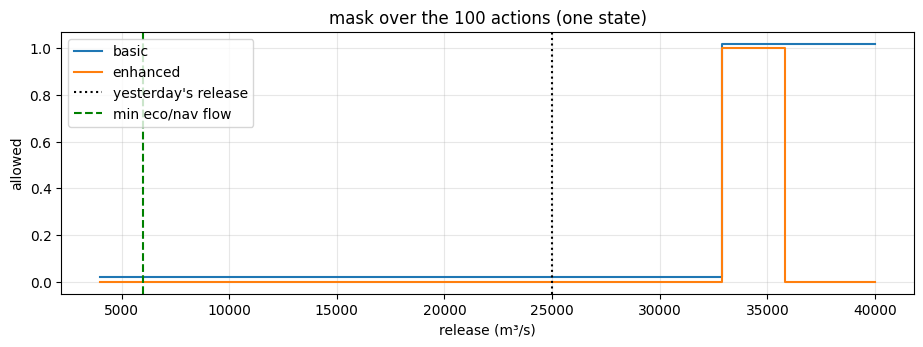

In [5]:
fig, ax = plt.subplots()
ax.plot(env_b.grid, env_b.action_mask().astype(int) + 0.02, drawstyle="steps-mid", label="basic")
ax.plot(env_e.grid, env_e.action_mask().astype(int), drawstyle="steps-mid", label="enhanced")
ax.axvline(env_e.prev_release, c="k", ls=":", label="yesterday's release"); ax.axvline(max(tr.Q_ECOLOGICAL, tr.Q_NAVIGATION), c="g", ls="--", label="min eco/nav flow")
ax.set_xlabel("release (m³/s)"); ax.set_ylabel("allowed"); ax.legend(); ax.grid(alpha=.3); ax.set_title("mask over the 100 actions (one state)")

### 에피소드 전체에서 마스크가 얼마나 좁아지는가

무작위 정책으로 1년을 돌리면서 매일 허용 액션 개수와 제약 비용을 기록합니다.

In [6]:
def random_policy(obs, mask):
    return np.random.choice(np.flatnonzero(mask))

records = []
for rule in ("none", "basic", "enhanced"):
    env = tr.ToyReservoirEnv(constraint_types=3, enable_action_mask=(rule != "none"), mask_rule_type=rule if rule != "none" else "basic")
    np.random.seed(0)
    obs, info = env.reset(seed=7, init_level=160)
    allowed, done = [], False
    while not done:
        mask = info["action_mask"] if env.enable_action_mask else np.ones(100, bool)
        allowed.append(mask.sum())
        obs, r, te, tu, info = env.step(random_policy(obs, mask)); done = te or tu
    log = pd.DataFrame(env.history); log["allowed_actions"] = allowed; log["rule"] = rule
    records.append(log)
logs = pd.concat(records)
logs.groupby("rule")[["allowed_actions", "reward", "constraint_cost", "cost_level", "cost_flood", "cost_ecological", "cost_action"]].mean().round(3)

,allowed_actions,reward,constraint_cost,cost_level,cost_flood,cost_ecological,cost_action
rule,,,,,,,
basic,48.321,-0.105,0.082,0.005,0.003,0.126,0.115
enhanced,28.964,0.019,0.070,0.005,0.000,0.108,0.060
none,100.000,-0.714,0.172,0.202,0.302,0.112,0.332


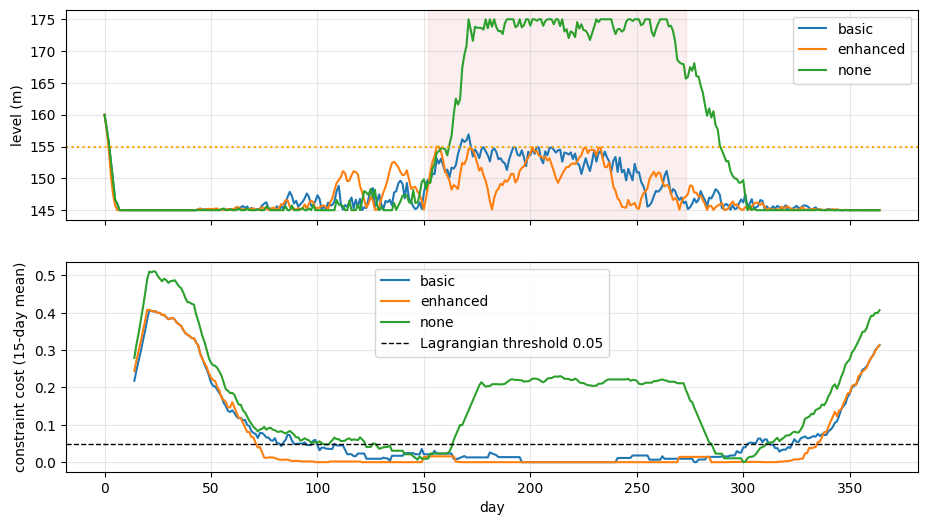

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for rule, g in logs.groupby("rule"):
    axes[0].plot(g.t, g.level, label=rule); axes[1].plot(g.t, g.constraint_cost.rolling(15).mean(), label=rule)
axes[0].axhline(tr.Z_FLOOD_LIMIT, c="orange", ls=":"); axes[0].axvspan(*tr.FLOOD_SEASON, color="tab:red", alpha=.08); axes[0].set_ylabel("level (m)"); axes[0].legend()
axes[1].axhline(0.05, c="k", ls="--", lw=1, label="Lagrangian threshold 0.05"); axes[1].set_ylabel("constraint cost (15-day mean)"); axes[1].set_xlabel("day"); axes[1].legend()
for a in axes: a.grid(alpha=.3)

## 정리

* **마스크**는 학습 없이도 제약 위반을 줄이는 하드 안전층입니다. 정책은 남은 액션 안에서만 탐색하므로 학습이 빨라지고 안전해집니다(실험 B).
* **비선형 매핑**은 이산 액션 격자의 해상도를 재배치합니다. 저수지 운영은 대부분의 날이 저·중방류 구간이므로 `square` 계열이 유리할 수 있습니다(실험 C).
* 두 스위치는 모두 `A3_Lagrangian` 위에 쌓입니다. 다음 노트북에서 PPO-Lagrangian 과 함께 실제로 학습해 봅니다.